6.183689531825208


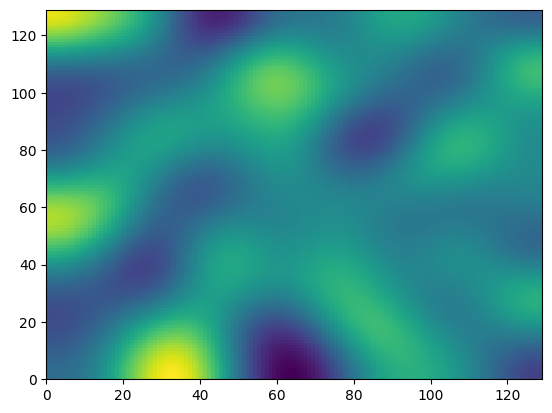

In [360]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft

nx = 129
ny = 129
Lx = 1
mu = 0.0
sigma = 1.0
rng = np.random.default_rng(seed=1990)
h = np.zeros((nx,ny))
x = np.linspace(0,Lx,nx)
y = np.linspace(0,Lx,nx)
xmap, ymap = np.meshgrid(x,y,indexing='ij')
ns = 10
a = rng.normal(loc=0.0, scale=100.0, size=(ns,ns))
b = rng.normal(loc=0.0, scale=100.0, size=(ns,ns))
#print(a)
for i in range(1,ns+1):
    for j in range(1,ns+1):
        if (4**2 < i**2 + j**2 < 10**2):
            h = h + a[i-1,j-1]*np.cos(np.pi*xmap*i/Lx)*np.cos(np.pi*ymap*j/Lx)/(i**2 + j**2)**(1.5) #**(0.5)
plt.pcolor(h)
print(np.amax(h))

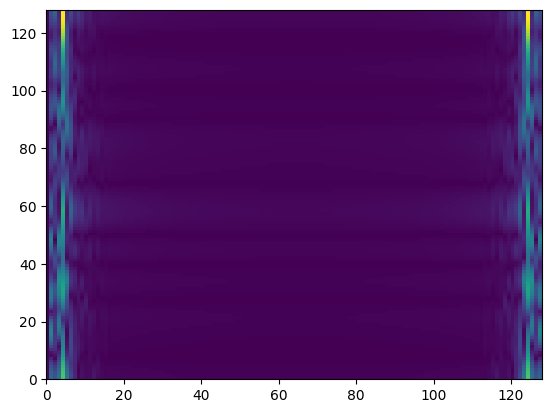

In [223]:
f = fft.fft(h)
plt.pcolor(np.absolute(f))

In [364]:
npts = 129
Lpts = npts-1
x1 = np.linspace(0,Lpts,npts)
y1 = np.linspace(0,Lpts,npts)
z1 = np.linspace(0,Lpts,npts)
x3, y3, z3 = np.meshgrid(x1,y1,z1,indexing='ij')

phi = np.ones_like(x3)
for i in range(0,npts):
    for j in range(0,npts):
        for k in range(0,npts):
            if ( y3[i,j,k] > h[i,k] + 0.75*Lpts):
                phi[i,j,k] = 0.0

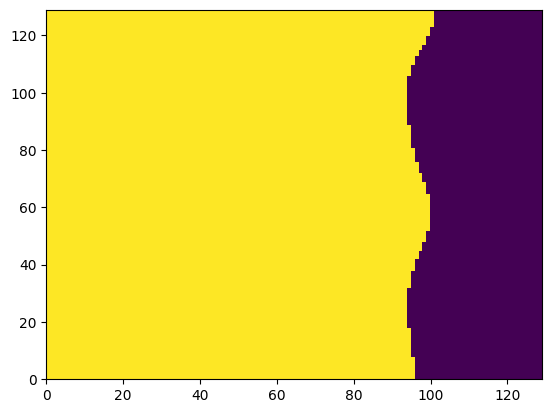

In [368]:
plt.pcolor(phi[:,:,10])

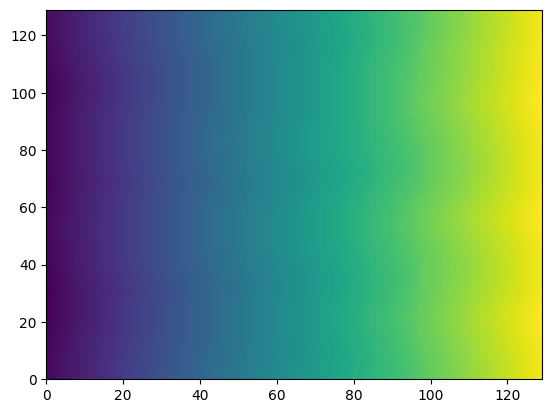

In [319]:
from scipy.ndimage import distance_transform_edt

dist = distance_transform_edt(1-phi) - distance_transform_edt(phi)
plt.pcolor(dist[:,:,10])

In [352]:
phi_init = np.ones_like(x3)
ell = 2.0*Lpts/40.0
for i in range(0,npts):
    for j in range(0,npts):
        for k in range(0,npts):
            if ( dist[i,j,k] > ell/2.0 ):
                phi_init[i,j,k] = 0.0
            else:
                if ( dist[i,j,k] < -ell/2.0 ):
                    phi_init[i,j,k] = 1.0
                else:
                    phi_init[i,j,k] = 0.5 - 0.5*np.sin(np.pi/ell*dist[i,j,k])
print(np.amax(phi_init))

1.0


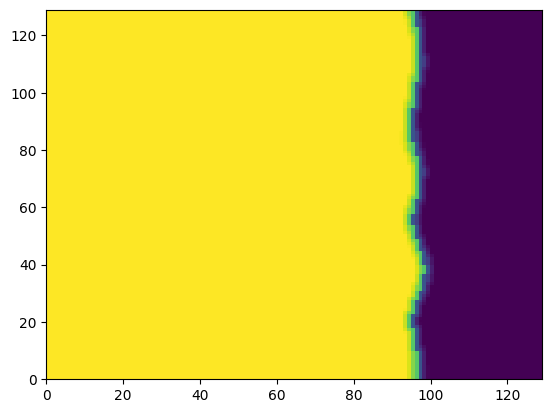

In [353]:
plt.pcolor(phi_init[:,:,14])

In [372]:
phi_init2 = np.ones_like(x3)
ell = 2.0*Lpts/40.0
for i in range(0,npts):
    for j in range(0,npts):
        for k in range(0,npts):
            distpt = y3[i,j,k] - (h[i,k] + 0.75*Lpts)
            if ( distpt > ell/2.0 ):
                phi_init2[i,j,k] = 0.0
            else:
                if ( distpt < -ell/2.0 ):
                    phi_init2[i,j,k] = 1.0
                else:
                    phi_init2[i,j,k] = 0.5 - 0.5*np.sin(np.pi/ell*distpt)
print(np.amax(phi_init2))

1.0


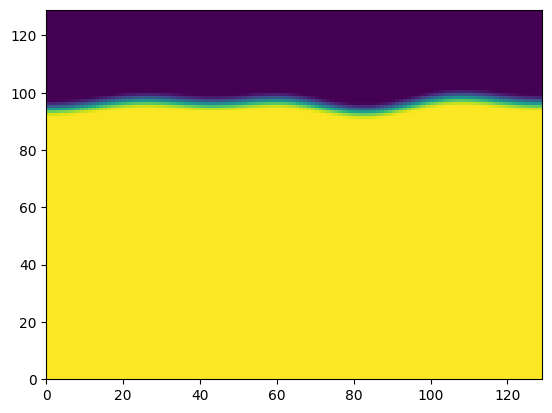

In [373]:
#plt.pcolor(phi_init2[:,:,100])
#plt.pcolor(phi_init2[:,:,80])
plt.pcolor(phi_init2[80,:,:])

In [374]:
f = open("dealloy_phi.in",'wb')
f.write(phi_init2.tobytes(order='F'))
f.close()